In [2]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import algoritma Isolation Forest dari Scikit-Learn
from sklearn.ensemble import IsolationForest

# Konfigurasi visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Load Data & Inspeksi Awal

In [3]:
# Membaca dataset dari folder raw
df = pd.read_csv('../data/milknew.csv') 

# Menampilkan 5 baris pertama
display(df.head())

# Menampilkan informasi tipe data dan jumlah kolom
print("\nInformasi Dataset:")
df.info()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


## Eksplorasi Fitur Kontinu vs Biner

In [4]:
# Memisahkan kolom berdasarkan tipe numerik kontinu dan biner/kategorikal
kolom_kontinu = ['pH', 'Temprature', 'Colour'] 
kolom_biner = ['Taste', 'Odor', 'Fat ', 'Turbidity']

# Menampilkan statistik deskriptif
print("Statistik Fitur Kontinu:")
display(df[kolom_kontinu].describe())

print("\nDistribusi Nilai pada Fitur Biner:")
for col in kolom_biner:
    print(df[col].value_counts(normalize=True).round(2) * 100) # Dalam persentase

Statistik Fitur Kontinu:


,pH,Temprature,Colour
count,1059.000000,1059.000000,1059.000000
mean,6.630123,44.226629,251.840415
std,1.399679,10.098364,4.307424
min,3.000000,34.000000,240.000000
25%,6.500000,38.000000,250.000000
50%,6.700000,41.000000,255.000000
75%,6.800000,45.000000,255.000000
max,9.500000,90.000000,255.000000



Distribusi Nilai pada Fitur Biner:
Taste
1    55.0
0    45.0
Name: proportion, dtype: float64
Odor
0    57.0
1    43.0
Name: proportion, dtype: float64
Fat 
1    67.0
0    33.0
Name: proportion, dtype: float64
Turbidity
0    51.0
1    49.0
Name: proportion, dtype: float64


## Membangun Model Deteksi Anomali : Isolation Forest

In [10]:
# Mendefinisikan fitur sensor yang akan dianalisis oleh mesin
# Pastikan nama kolom sama persis dengan output df.info() di Cell 2
fitur_sensor = ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour']

# Inisialisasi Model Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.40, random_state=42)

# Melatih model sekaligus melakukan prediksi
# Hasil: 1 = Normal, -1 = Anomali
df['status_anomali'] = iso_forest.fit_predict(df[fitur_sensor])

# Menghitung skor anomali (semakin negatif = semakin aneh datanya)
df['skor_anomali'] = iso_forest.decision_function(df[fitur_sensor])

# Menghitung jumlah data normal dan anomali
jumlah_status = df['status_anomali'].value_counts()
print(f"Data Normal (1): {jumlah_status[1]} baris")
print(f"Data Anomali (-1): {jumlah_status[-1]} baris")

Data Normal (1): 643 baris
Data Anomali (-1): 416 baris


## Visualisasi Anomali : Suhu vs Ph

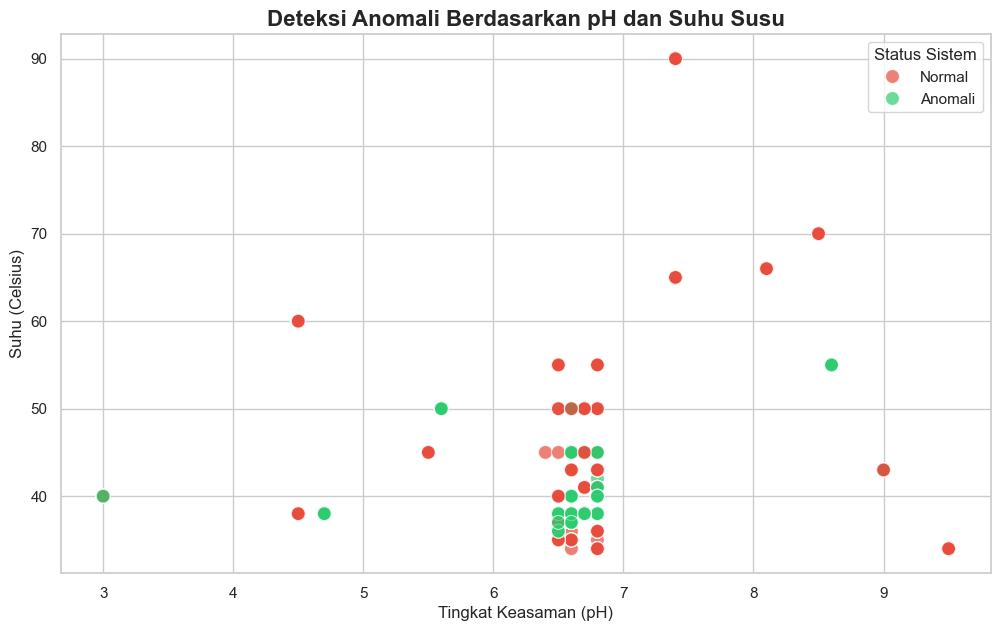

In [13]:
# Membuat plot titik antara Suhu dan pH
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='pH', 
    y='Temprature', 
    hue='status_anomali', 
    palette={1: '#2ecc71', -1: '#e74c3c'}, # Hijau untuk normal, Merah untuk anomali
    alpha=0.7,
    s=100
)

plt.title('Deteksi Anomali Berdasarkan pH dan Suhu Susu', fontsize=16, fontweight='bold')
plt.xlabel('Tingkat Keasaman (pH)', fontsize=12)
plt.ylabel('Suhu (Celsius)', fontsize=12)

# Kustomisasi Legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Normal', 'Anomali'], title='Status Sistem', loc='best')

plt.show()

## Evaluasi Model : Pseudo-Supervised Evaluation
- Memakai kolom 'Grade' untuk menguji prediksi model unsupervised.

=== LAPORAN EVALUASI ISOLATION FOREST ===
Ingat: Model tidak pernah melihat kolom 'Grade' saat training!

              precision    recall  f1-score   support

          -1       0.62      0.60      0.61       429
           1       0.73      0.75      0.74       630

    accuracy                           0.69      1059
   macro avg       0.68      0.67      0.67      1059
weighted avg       0.69      0.69      0.69      1059



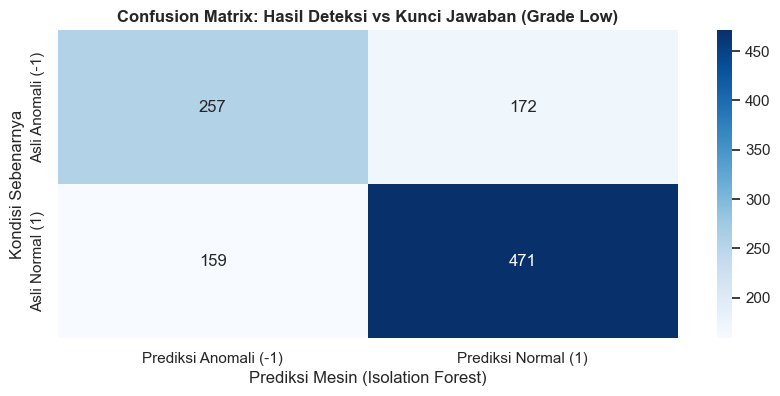

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Buat 'Kunci Jawaban' (Ground Truth) dari kolom Grade yang sebelumnya kita abaikan
# Kita asumsikan susu Grade 'low' adalah anomali murni (-1), dan sisanya normal (1)
df['ground_truth'] = df['Grade'].apply(lambda x: -1 if x.lower() == 'low' else 1)

# 2. Tampilkan Laporan Klasifikasi
print("=== LAPORAN EVALUASI ISOLATION FOREST ===")
print("Ingat: Model tidak pernah melihat kolom 'Grade' saat training!\n")
print(classification_report(df['ground_truth'], df['status_anomali']))

# 3. Visualisasi Confusion Matrix dengan layout horizontal agar lebih luas dan rapi
cm = confusion_matrix(df['ground_truth'], df['status_anomali'])

plt.figure(figsize=(10, 4)) # Menggunakan layout yang sedikit melebar ke samping
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Anomali (-1)', 'Prediksi Normal (1)'], 
            yticklabels=['Asli Anomali (-1)', 'Asli Normal (1)'])

plt.title('Confusion Matrix: Hasil Deteksi vs Kunci Jawaban (Grade Low)', fontweight='bold')
plt.xlabel('Prediksi Mesin (Isolation Forest)')
plt.ylabel('Kondisi Sebenarnya')
plt.show()

## Analisis Akar Masalah (Root Cause) & Simulasi Rekomendasi (Knowledge-Based Recommendation System)

In [12]:
# 1. Bandingkan rata-rata sensor antara Normal dan Anomali
perbandingan = df.groupby('status_anomali')[fitur_sensor].mean().round(2)
perbandingan.index = ['Anomali (-1)', 'Normal (1)']
print("--- PERBANDINGAN RATA-RATA SENSOR ---")
display(perbandingan)

print("\n--- SIMULASI KARTU REKOMENDASI UNTUK KNOWLEDGE WORKER ---")
# 2. Ambil data anomali saja
anomali_df = df[df['status_anomali'] == -1]

# 3. Buat simulasi logika deteksi masalah untuk 5 data anomali pertama
for index, row in anomali_df.head(5).iterrows():
    masalah = []
    
    # Aturan Bisnis (Business Rules) dengan Skala Prioritas
    
    # 1. Parameter Kimia (pH)
    if row['pH'] < 6.4: 
        masalah.append("pH < 6.4: Asiditas tinggi (Risiko fermentasi bakteri)")
    elif row['pH'] > 6.8: 
        masalah.append("pH > 6.8: Basa tidak wajar (Cek residu bahan pembersih CIP / Mastitis)")
        
    # 2. Parameter Termal (Suhu) - Dibuat bertingkat
    if row['Temprature'] >= 50: 
        masalah.append("Suhu Kritis (>50°C): Kegagalan total sistem pendingin tangki")
    elif 40 <= row['Temprature'] < 50:
        masalah.append("Suhu Warning (40-49°C): Fluktuasi termal terdeteksi")
        
    # 3. Parameter Organoleptik & Fisik
    if row['Odor'] == 0: 
        masalah.append("Uji Organoleptik Gagal: Terdeteksi bau menyimpang")
        
    if row['Turbidity'] == 1: 
        masalah.append("Fisik: Kekeruhan tinggi (Indikasi penggumpalan protein/filtrasi buruk)")

    # Menggabungkan teks masalah
    indikasi = " + ".join(masalah) if masalah else "Kombinasi Sensor Tidak Wajar"
    
    # Menampilkan Output
    print(f"Batch ID: {index} | pH: {row['pH']}, Suhu: {row['Temprature']}°C")
    print(f"Indikasi  : {indikasi}")
    print("-" * 50)

--- PERBANDINGAN RATA-RATA SENSOR ---


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
Anomali (-1),6.81,48.50,0.51,0.42,0.50,0.52,250.21
Normal (1),6.52,41.46,0.57,0.44,0.78,0.47,252.90



--- SIMULASI KARTU REKOMENDASI UNTUK KNOWLEDGE WORKER ---
Batch ID: 1 | pH: 6.6, Suhu: 36°C
Indikasi  : Fisik: Kekeruhan tinggi (Indikasi penggumpalan protein/filtrasi buruk)
--------------------------------------------------
Batch ID: 2 | pH: 8.5, Suhu: 70°C
Indikasi  : pH > 6.8: Basa tidak wajar (Cek residu bahan pembersih CIP / Mastitis) + Suhu Kritis (>50°C): Kegagalan total sistem pendingin tangki + Fisik: Kekeruhan tinggi (Indikasi penggumpalan protein/filtrasi buruk)
--------------------------------------------------
Batch ID: 3 | pH: 9.5, Suhu: 34°C
Indikasi  : pH > 6.8: Basa tidak wajar (Cek residu bahan pembersih CIP / Mastitis) + Fisik: Kekeruhan tinggi (Indikasi penggumpalan protein/filtrasi buruk)
--------------------------------------------------
Batch ID: 6 | pH: 5.5, Suhu: 45°C
Indikasi  : pH < 6.4: Asiditas tinggi (Risiko fermentasi bakteri) + Suhu Warning (40-49°C): Fluktuasi termal terdeteksi + Uji Organoleptik Gagal: Terdeteksi bau menyimpang + Fisik: Kekeruhan tin

## Eksport Model : pkl

In [ ]:
import joblib
import os
from sklearn.ensemble import IsolationForest

# 1. Pastikan model menggunakan parameter terbaik hasil tuning kita (0.40)
fitur_sensor = ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour']
iso_forest_final = IsolationForest(n_estimators=100, contamination=0.40, random_state=42)

# Latih (fit) model dengan data kita
iso_forest_final.fit(df[fitur_sensor])

# 2. Atur path ke folder saat ini 
folder_path = '.'

# 3. Ekspor dan simpan model
file_model = os.path.join(folder_path, 'iforest_model.pkl')
joblib.dump(iso_forest_final, file_model)

print(f"Model final berhasil diamankan ke dalam: {file_model}")

Model final berhasil diamankan ke dalam: ../app/model\iforest_model.pkl
